<a href="https://colab.research.google.com/github/britobruna/ESTATISTICA-PPEC0039/blob/main/Testes_Normalidade_Homocedasticidade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  1. Introdução

<div align="justify">

A análise estatística desempenha papel fundamental no planejamento e interpretação de experimentos em engenharia civil, especialmente em estudos envolvendo materiais cimentícios, compósitos reforçados com fibras e modificações de matriz.

Em ensaios experimentais, é comum comparar diferentes grupos de resultados, verificar diferenças entre tratamentos ou avaliar o comportamento mecânico de materiais. Entretanto, antes da aplicação de diversos testes estatísticos paramétricos, como análise de variância (ANOVA) e regressão linear, é necessário verificar se determinados pressupostos estatísticos são atendidos.

Entre esses pressupostos, destacam-se a normalidade dos dados e a homogeneidade das variâncias (homocedasticidade). A verificação dessas condições é importante para garantir a validade das inferências estatísticas realizadas.

Segundo Montgomery e Runger (2014), a análise prévia da distribuição dos dados e do comportamento das variâncias constitui etapa essencial na interpretação correta de resultados experimentais em engenharia.

Neste material, serão abordados os principais testes de normalidade e homocedasticidade, incluindo interpretações gráficas, testes analíticos e aplicações computacionais utilizando Python.

</div>

##  1.1. Testes de normalidade

<div align="justify">

Um conjunto de dados apresenta normalidade quando sua distribuição se aproxima da distribuição normal, também conhecida como distribuição Gaussiana.

A distribuição normal possui formato simétrico em torno da média e é amplamente utilizada na modelagem de fenômenos naturais e experimentais. Em engenharia, diversas propriedades mecânicas apresentam comportamento aproximadamente normal, como resistência à compressão, resistência à flexão e módulo de elasticidade.

A verificação da normalidade é importante porque muitos testes estatísticos clássicos assumem que os dados seguem distribuição normal. Caso essa condição não seja atendida, os resultados podem apresentar interpretações inadequadas.

</div>

<div style="background-color:#f9f0ff; padding:15px; border-left:5px solid #722ed1">

**Definição:**

Os testes de normalidade são ferramentas estatísticas utilizadas para verificar se um conjunto de dados apresenta distribuição aproximadamente normal.

</div>

###  Importância da Normalidade

<div align="justify">

A avaliação da normalidade é importante em diversas aplicações estatísticas, principalmente porque muitos métodos paramétricos dependem desse pressuposto.

A verificação da normalidade é frequentemente realizada antes da aplicação de:

- análise de variância (ANOVA);
- regressão linear;
- testes t;
- análise de médias;
- planejamento experimental.

Na engenharia de materiais, por exemplo, a normalidade pode ser avaliada em resultados de resistência mecânica, absorção de água, massa específica e deformações experimentais.

</div>

<div align="justify">

A normalidade pode ser avaliada tanto por métodos gráficos quanto por testes analíticos. Entre os métodos gráficos mais utilizados destaca-se o gráfico QQ-Plot, amplamente empregado pela sua simplicidade visual e facilidade de interpretação.

</div>

## 📉 1.1 Gráfico QQ-Plot

<div align="justify">

O gráfico QQ-Plot (Quantile-Quantile Plot) é uma ferramenta gráfica utilizada para comparar a distribuição dos dados observados com uma distribuição teórica, geralmente a distribuição normal.

Nesse gráfico, os quantis observados da amostra são comparados com os quantis esperados da distribuição normal. Quando os pontos se aproximam de uma linha reta, considera-se que os dados apresentam comportamento aproximadamente normal.

</div>

<div style="background-color:#fffbe6; padding:15px; border-left:5px solid #faad14">

**Interpretação do QQ-Plot:**

- pontos próximos da reta → dados aproximadamente normais;
- desvios acentuados da reta → possível não normalidade;
- curvaturas → assimetria ou caudas não normais;
- pontos extremos afastados → possíveis outliers.

</div>

<div style="background-color:#f0f8ff; padding:15px; border-left:5px solid #69b1ff">

**Sugestão de Figura:**

Inserir exemplo ilustrativo de QQ-Plot contendo:
- distribuição aproximadamente normal;
- distribuição assimétrica;
- comparação visual entre diferentes comportamentos.

Sugestões:
- gráfico gerado em Python;
- imagem de livro/artigo;
- comparação entre dados normais e não normais.

</div>

### 💻 Implementação Computacional — QQ-Plot

<div align="justify">

A construção computacional do QQ-Plot permite visualizar de forma prática o comportamento dos dados experimentais em relação à distribuição normal.

No exemplo a seguir, será gerada uma amostra simulada representando resultados de resistência à flexão de compósitos cimentícios reforçados com fibras. Em seguida, será construído o gráfico QQ-Plot para avaliar visualmente a normalidade dos dados.

</div>

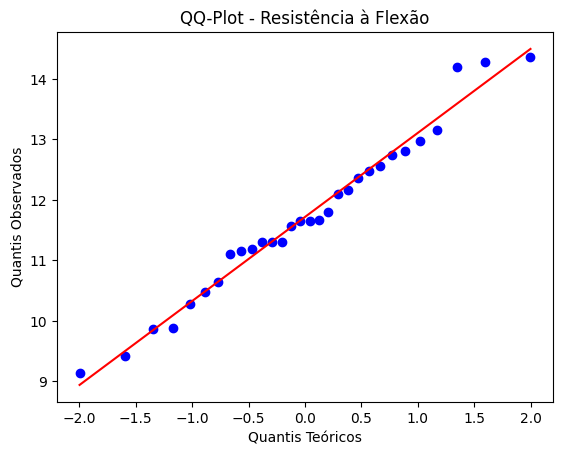

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Gerando amostra simulada
np.random.seed(42)

dados = np.random.normal(loc=12, scale=1.5, size=30)

# Criando QQ-Plot
plt.figure()

stats.probplot(dados, dist="norm", plot=plt)

plt.title("QQ-Plot - Resistência à Flexão")
plt.xlabel("Quantis Teóricos")
plt.ylabel("Quantis Observados")

plt.show()

### 📊 Interpretação dos Resultados

<div align="justify">

Observa-se que os pontos do gráfico encontram-se próximos da reta de referência, indicando que os dados apresentam comportamento aproximadamente normal.

Pequenos desvios podem ocorrer devido à variabilidade amostral, especialmente em conjuntos de dados reduzidos. Entretanto, quando os pontos seguem tendência linear sem grandes afastamentos, considera-se que o pressuposto de normalidade pode ser aceito visualmente.

Na prática experimental, essa análise auxilia na escolha adequada dos testes estatísticos que poderão ser aplicados posteriormente.

</div>

## ⚖️ Vantagens e Limitações do QQ-Plot

<div align="justify">

### ✔ Vantagens
- interpretação visual simples;
- identificação rápida de assimetria;
- permite detectar outliers;
- não depende diretamente de p-valores.

### ❌ Limitações
- interpretação subjetiva;
- depende da experiência do analista;
- menos eficiente para pequenas diferenças de normalidade;
- não substitui completamente os testes analíticos.

</div>

## 🧪 1.2 Teste de Shapiro-Wilk

<div align="justify">

O teste de Shapiro-Wilk é um dos testes de normalidade mais utilizados em análises estatísticas, especialmente para conjuntos de dados com tamanho amostral reduzido.

Proposto por Shapiro e Wilk em 1965, esse teste avalia se os dados observados apresentam comportamento compatível com uma distribuição normal. Sua ampla utilização está relacionada à elevada sensibilidade na detecção de desvios de normalidade.

Segundo Razali e Wah (2011), o teste de Shapiro-Wilk apresenta elevado poder estatístico quando comparado a outros testes de normalidade, sendo frequentemente recomendado para pequenas amostras.

</div>

<div style="background-color:#f9f0ff; padding:15px; border-left:5px solid #722ed1">

**Definição:**

O teste de Shapiro-Wilk verifica se um conjunto de dados pode ser considerado proveniente de uma distribuição normal.

</div>

### 📌 Hipóteses do Teste

<div align="justify">

O teste baseia-se nas seguintes hipóteses:

- Hipótese nula (\( H_0 \)): os dados seguem distribuição normal;
- Hipótese alternativa (\( H_1 \)): os dados não seguem distribuição normal.

A decisão é geralmente realizada a partir do p-valor obtido no teste.

</div>

### 📊 Interpretação do p-valor

<div align="justify">

A interpretação do teste é realizada comparando-se o p-valor com o nível de significância adotado, geralmente \( \alpha = 0,05 \).

- Se \( p > 0,05 \), não se rejeita \( H_0 \), indicando normalidade;
- Se \( p \leq 0,05 \), rejeita-se \( H_0 \), indicando possível não normalidade.

É importante destacar que o teste não “prova” normalidade, mas apenas avalia evidências estatísticas de desvio em relação à distribuição normal.

</div>

### ⚙️ Princípio do Teste

<div align="justify">

O teste de Shapiro-Wilk compara a ordenação dos dados observados com os valores esperados para uma distribuição normal.

De forma simplificada, o teste avalia o grau de alinhamento entre os dados amostrais e os quantis esperados da normalidade. Quanto maior a discrepância observada, maior a evidência de não normalidade.

</div>

### 🔎 Características do Teste

<div align="justify">

O teste de Shapiro-Wilk apresenta características importantes:

- elevado poder estatístico;
- eficiente para pequenas amostras;
- amplamente utilizado em artigos científicos;
- sensível à presença de assimetria e outliers;
- adequado para diversas aplicações experimentais.

Na engenharia de materiais, é frequentemente utilizado para verificar a normalidade de resultados mecânicos antes da aplicação de testes comparativos entre grupos experimentais.

</div>

## ⚖️ Vantagens e Limitações

<div align="justify">

### ✔ Vantagens
- alto poder de detecção;
- adequado para pequenas amostras;
- interpretação relativamente simples;
- amplamente implementado em softwares estatísticos.

### ❌ Limitações
- sensível a outliers;
- pode rejeitar normalidade em grandes amostras devido a pequenos desvios;
- interpretação deve ser complementada por análise gráfica.

</div>

<div style="background-color:#fffbe6; padding:15px; border-left:5px solid #faad14">

**Aplicação na Engenharia de Materiais:**

O teste de Shapiro-Wilk pode ser aplicado para avaliar a normalidade de resultados experimentais de resistência à flexão, resistência à compressão, absorção de água, módulo de elasticidade e propriedades associadas ao desempenho de compósitos cimentícios reforçados com fibras.

A verificação da normalidade é especialmente importante antes da aplicação de testes paramétricos comparativos entre diferentes formulações de argamassa ou diferentes tratamentos aplicados às fibras.

</div>

<div style="background-color:#fff1f0; padding:15px; border-left:5px solid #ff4d4f">

**Observação Importante:**

A avaliação da normalidade não deve ser realizada exclusivamente por testes analíticos. Recomenda-se combinar testes estatísticos com métodos gráficos, como histogramas e QQ-Plots, permitindo uma interpretação mais robusta dos dados.

</div>

## 🧪 1.3 Teste de Kolmogorov-Smirnov

<div align="justify">

O teste de Kolmogorov-Smirnov, frequentemente abreviado como teste KS, é um teste estatístico utilizado para comparar a distribuição acumulada observada de uma amostra com uma distribuição teórica de referência, como a distribuição normal.

Esse teste foi desenvolvido por Andrey Kolmogorov e posteriormente aprimorado por Nikolai Smirnov, sendo amplamente empregado em análises estatísticas para verificar aderência entre distribuições.

Diferentemente do teste de Shapiro-Wilk, o teste KS baseia-se na comparação entre funções distribuição acumulada, avaliando a maior diferença observada entre a distribuição empírica da amostra e a distribuição teórica esperada.

</div>

<div style="background-color:#f9f0ff; padding:15px; border-left:5px solid #722ed1">

**Definição:**

O teste de Kolmogorov-Smirnov verifica se a distribuição acumulada dos dados observados difere significativamente de uma distribuição teórica especificada.

</div>

### 📌 Hipóteses do Teste

<div align="justify">

As hipóteses do teste são:

- Hipótese nula (\( H_0 \)): os dados seguem a distribuição teórica especificada;
- Hipótese alternativa (\( H_1 \)): os dados não seguem a distribuição teórica especificada.

Quando aplicado para avaliar normalidade, a distribuição teórica considerada é a distribuição normal.

</div>

### ⚙️ Princípio do Teste

<div align="justify">

O teste de Kolmogorov-Smirnov compara duas funções distribuição acumulada:

- distribuição acumulada observada da amostra;
- distribuição acumulada teórica esperada.

A estatística do teste corresponde à maior distância vertical entre essas duas curvas acumuladas.

Quanto maior essa diferença, maior a evidência de que os dados não seguem a distribuição analisada.

</div>

<div style="background-color:#f0f8ff; padding:15px; border-left:5px solid #69b1ff">

**Sugestão de Figura:**

Inserir gráfico comparando:
- função distribuição acumulada empírica;
- função distribuição acumulada teórica normal.

Sugestões:
- gráfico ilustrando a distância máxima entre as curvas;
- esquema visual da estatística D do teste KS;
- figura mostrando aderência e não aderência à normalidade.

</div>

### 📊 Interpretação do p-valor

<div align="justify">

A interpretação do teste de Kolmogorov-Smirnov é realizada por meio do p-valor:

- Se \( p > 0,05 \), não se rejeita \( H_0 \), indicando aderência à distribuição analisada;
- Se \( p \leq 0,05 \), rejeita-se \( H_0 \), indicando possível não aderência.

Assim como nos demais testes de normalidade, o resultado deve ser interpretado juntamente com análises gráficas e conhecimento experimental do problema estudado.

</div>

### 🔎 Características do Teste KS

<div align="justify">

O teste de Kolmogorov-Smirnov apresenta características importantes:

- pode ser aplicado a diferentes distribuições teóricas;
- utiliza funções acumuladas;
- não depende diretamente de histogramas;
- possui interpretação relativamente simples;
- pode ser utilizado para comparar duas amostras.

Entretanto, quando os parâmetros da distribuição normal são estimados a partir da própria amostra, o teste KS clássico apresenta limitações, sendo recomendadas adaptações, como o teste de Lilliefors.

</div>

## ⚖️ Vantagens e Limitações

<div align="justify">

### ✔ Vantagens
- aplicação relativamente simples;
- pode ser utilizado para diferentes distribuições;
- comparação direta entre distribuições acumuladas;
- bastante difundido em softwares estatísticos.

### ❌ Limitações
- menor poder estatístico em comparação ao Shapiro-Wilk;
- sensível ao tamanho da amostra;
- desempenho reduzido quando os parâmetros da distribuição são estimados da própria amostra;
- menor sensibilidade em regiões de cauda da distribuição.

</div>

<div style="background-color:#fffbe6; padding:15px; border-left:5px solid #faad14">

**Comparação com o teste de Shapiro-Wilk:**

Embora ambos sejam utilizados para avaliação da normalidade, o teste de Shapiro-Wilk geralmente apresenta maior poder estatístico para pequenas amostras, sendo frequentemente preferido em estudos experimentais na engenharia.

O teste KS, por outro lado, destaca-se pela flexibilidade na comparação entre distribuições acumuladas e pela possibilidade de aplicação em diferentes contextos estatísticos.

</div>

<div style="background-color:#e6f7ff; padding:15px; border-left:5px solid #1890ff">

**Aplicação na Engenharia de Materiais:**

O teste de Kolmogorov-Smirnov pode ser utilizado para avaliar a aderência de propriedades mecânicas experimentais à distribuição normal, como resistência à compressão, resistência à tração e absorção de água em compósitos cimentícios.

Além disso, o teste pode auxiliar na comparação entre distribuições obtidas para diferentes formulações de materiais, tratamentos de fibras ou condições de cura.

</div>

<div style="background-color:#fff1f0; padding:15px; border-left:5px solid #ff4d4f">

**Observação Importante:**

O teste KS clássico pressupõe que os parâmetros da distribuição teórica sejam previamente conhecidos. Quando média e desvio padrão são estimados a partir da própria amostra, recomenda-se utilizar adaptações específicas, como o teste de Lilliefors.

</div>

## 🧪 1.4 Teste de Anderson-Darling

<div align="justify">

O teste de Anderson-Darling é um teste estatístico de aderência utilizado para avaliar se um conjunto de dados segue uma determinada distribuição teórica, sendo amplamente aplicado na verificação da normalidade.

Esse teste consiste em uma modificação do teste de Kolmogorov-Smirnov, porém atribuindo maior peso às regiões de cauda da distribuição. Dessa forma, o teste de Anderson-Darling apresenta elevada sensibilidade para detectar desvios de normalidade associados a valores extremos.

Na prática experimental, essa característica torna o teste particularmente útil em situações em que outliers, assimetrias ou caudas anormais podem influenciar significativamente a interpretação dos resultados.

</div>

<div style="background-color:#f9f0ff; padding:15px; border-left:5px solid #722ed1">

**Definição:**

O teste de Anderson-Darling verifica se um conjunto de dados apresenta aderência a uma distribuição teórica, atribuindo maior sensibilidade às extremidades da distribuição.

</div>

### 📌 Hipóteses do Teste

<div align="justify">

As hipóteses do teste são:

- Hipótese nula (\( H_0 \)): os dados seguem a distribuição especificada;
- Hipótese alternativa (\( H_1 \)): os dados não seguem a distribuição especificada.

Quando aplicado à análise de normalidade, a distribuição teórica considerada é a distribuição normal.

</div>

### ⚙️ Princípio do Teste

<div align="justify">

O teste de Anderson-Darling baseia-se na comparação entre a distribuição acumulada observada da amostra e a distribuição acumulada teórica esperada.

Entretanto, diferentemente do teste de Kolmogorov-Smirnov, o Anderson-Darling atribui maior importância aos desvios observados nas regiões de cauda da distribuição. Assim, pequenas discrepâncias em valores extremos tendem a exercer maior influência sobre a estatística do teste.

Essa característica torna o método especialmente eficiente na detecção de distribuições assimétricas ou com caudas mais pesadas que a distribuição normal.

</div>

### 📊 Interpretação do Teste

<div align="justify">

A interpretação do teste de Anderson-Darling é realizada a partir da estatística calculada e dos valores críticos associados a diferentes níveis de significância.

De forma geral:

- valores menores da estatística indicam maior aderência à distribuição analisada;
- valores maiores indicam possível não aderência.

Em softwares estatísticos, a interpretação pode ser realizada diretamente por meio do p-valor ou pela comparação entre a estatística calculada e os valores críticos fornecidos.

</div>

<div style="background-color:#f0f8ff; padding:15px; border-left:5px solid #69b1ff">

**Sugestão de Figura:**

Inserir gráfico ilustrando:
- comparação entre distribuição normal e distribuição com caudas mais pesadas;
- influência de outliers nas regiões extremas;
- representação visual da sensibilidade do teste às caudas da distribuição.

Sugestões:
- comparação entre histogramas;
- curva normal versus distribuição assimétrica;
- esquema destacando regiões de cauda.

</div>

### 🔎 Características do Teste

<div align="justify">

O teste de Anderson-Darling apresenta características importantes:

- elevada sensibilidade a desvios nas caudas;
- bom desempenho para detecção de assimetrias;
- maior poder estatístico em determinadas situações;
- aplicável a diferentes distribuições teóricas;
- amplamente utilizado em confiabilidade e análise experimental.

Na engenharia experimental, esse teste é particularmente útil quando valores extremos podem impactar significativamente a interpretação dos resultados.

</div>

## ⚖️ Vantagens e Limitações

<div align="justify">

### ✔ Vantagens
- elevada sensibilidade nas regiões de cauda;
- eficiente para detectar outliers e assimetrias;
- maior poder estatístico em diversas aplicações;
- adequado para análises experimentais mais rigorosas.

### ❌ Limitações
- interpretação um pouco menos intuitiva;
- maior sensibilidade pode levar à rejeição da normalidade por pequenos desvios;
- depende de valores críticos específicos para cada distribuição analisada.

</div>

<div style="background-color:#fffbe6; padding:15px; border-left:5px solid #faad14">

**Comparação com outros testes de normalidade:**

O teste de Anderson-Darling geralmente apresenta maior sensibilidade nas extremidades da distribuição quando comparado ao teste KS. Em relação ao teste de Shapiro-Wilk, ambos costumam apresentar bom desempenho, porém o Anderson-Darling destaca-se especialmente em situações envolvendo caudas não normais ou presença de outliers.

</div>

<div style="background-color:#e6f7ff; padding:15px; border-left:5px solid #1890ff">

**Aplicação na Engenharia de Materiais:**

O teste de Anderson-Darling pode ser aplicado na análise de propriedades mecânicas sujeitas à ocorrência de valores extremos, como resistência à tração de fibras vegetais, resistência à flexão de compósitos cimentícios e ensaios experimentais com elevada variabilidade.

Essa abordagem é particularmente relevante em materiais frágeis ou heterogêneos, nos quais pequenas alterações experimentais podem gerar respostas significativamente distintas.

</div>

<div style="background-color:#fff1f0; padding:15px; border-left:5px solid #ff4d4f">

**Observação Importante:**

Em conjuntos de dados experimentais com presença de outliers ou elevada dispersão, o teste de Anderson-Darling tende a apresentar maior sensibilidade do que outros testes de normalidade. Por esse motivo, recomenda-se interpretar seus resultados em conjunto com métodos gráficos e análise do contexto experimental.

</div>

## 🧪 1.5 Teste de Cramér-von Mises

<div align="justify">

O teste de Cramér-von Mises é um teste estatístico de aderência utilizado para verificar se um conjunto de dados segue uma distribuição teórica específica, como a distribuição normal.

Assim como os testes de Kolmogorov-Smirnov e Anderson-Darling, o método baseia-se na comparação entre a distribuição acumulada observada da amostra e a distribuição acumulada teórica esperada. Entretanto, o teste de Cramér-von Mises considera as discrepâncias ao longo de toda a distribuição, buscando avaliar o ajuste global entre os dados observados e o modelo teórico.

Esse teste apresenta abordagem intermediária entre o teste KS e o Anderson-Darling, sendo menos focado apenas nas regiões de cauda e mais voltado à aderência geral da distribuição.

</div>

<div style="background-color:#f9f0ff; padding:15px; border-left:5px solid #722ed1">

**Definição:**

O teste de Cramér-von Mises avalia a aderência entre a distribuição acumulada observada e a distribuição acumulada teórica por meio da soma das discrepâncias observadas ao longo de toda a distribuição.

</div>

### 📌 Hipóteses do Teste

<div align="justify">

As hipóteses do teste são:

- Hipótese nula (\( H_0 \)): os dados seguem a distribuição teórica especificada;
- Hipótese alternativa (\( H_1 \)): os dados não seguem a distribuição teórica especificada.

Quando aplicado à análise de normalidade, considera-se a distribuição normal como modelo teórico de referência.

</div>

### ⚙️ Princípio do Teste

<div align="justify">

O teste de Cramér-von Mises compara a distribuição acumulada observada da amostra com a distribuição acumulada teórica esperada, calculando uma medida global das diferenças existentes entre ambas.

Diferentemente do teste de Kolmogorov-Smirnov, que utiliza apenas a maior discrepância observada, o teste de Cramér-von Mises considera o comportamento de toda a distribuição, proporcionando avaliação mais equilibrada do ajuste global dos dados.

</div>

<div style="background-color:#f0f8ff; padding:15px; border-left:5px solid #69b1ff">

**Sugestão de Figura:**

Inserir figura ilustrando:
- comparação entre distribuição acumulada observada e teórica;
- diferença global entre curvas;
- comparação conceitual entre KS, Anderson-Darling e Cramér-von Mises.

Sugestões:
- gráfico de funções acumuladas;
- esquema mostrando avaliação global da distribuição;
- fluxograma comparativo entre os testes.

</div>

### 📊 Interpretação do Teste

<div align="justify">

A interpretação do teste de Cramér-von Mises baseia-se na estatística calculada e no respectivo p-valor.

De forma geral:

- valores menores da estatística indicam maior aderência à distribuição analisada;
- valores maiores indicam possíveis desvios em relação à distribuição teórica.

A decisão estatística é realizada comparando-se o p-valor ao nível de significância adotado.

</div>

### 🔎 Características do Teste

<div align="justify">

O teste de Cramér-von Mises apresenta características importantes:

- avaliação global da aderência da distribuição;
- menor dependência de discrepâncias localizadas;
- abordagem mais equilibrada ao longo da distribuição;
- adequado para diferentes distribuições teóricas;
- interpretação baseada em funções acumuladas.

Esse teste é frequentemente utilizado em análises estatísticas mais robustas e em estudos de aderência probabilística.

</div>

## ⚖️ Vantagens e Limitações

<div align="justify">

### ✔ Vantagens
- considera toda a distribuição;
- boa avaliação do ajuste global;
- menos dependente de uma única discrepância;
- adequado para análises de aderência mais amplas.

### ❌ Limitações
- menor sensibilidade a discrepâncias extremas;
- menos intuitivo visualmente;
- menos difundido em aplicações experimentais rotineiras;
- interpretação geralmente realizada com auxílio computacional.

</div>

<div style="background-color:#fffbe6; padding:15px; border-left:5px solid #faad14">

**Comparação com outros testes:**

O teste de Cramér-von Mises apresenta abordagem intermediária entre o teste KS e o Anderson-Darling.

Enquanto o teste KS enfatiza a maior discrepância observada e o Anderson-Darling atribui maior peso às regiões de cauda, o Cramér-von Mises busca avaliar o ajuste global da distribuição de maneira mais uniforme.

</div>

<div style="background-color:#e6f7ff; padding:15px; border-left:5px solid #1890ff">

**Aplicação na Engenharia de Materiais:**

O teste de Cramér-von Mises pode ser utilizado para avaliar o ajuste global de propriedades experimentais associadas a materiais cimentícios, como resistência mecânica, absorção de água e módulo de elasticidade.

Essa abordagem pode ser útil em estudos envolvendo diferentes formulações de argamassas, tratamentos superficiais de fibras vegetais ou modificações na matriz cimentícia.

</div>

<div style="background-color:#fff1f0; padding:15px; border-left:5px solid #ff4d4f">

**Observação Importante:**

Embora apresente boa capacidade de avaliação global da aderência dos dados, o teste de Cramér-von Mises é menos utilizado em análises experimentais rotineiras quando comparado ao Shapiro-Wilk ou Anderson-Darling. Ainda assim, sua utilização pode complementar a interpretação estatística em estudos mais detalhados.

</div>

## 🧪 1.6 Teste de Lilliefors

<div align="justify">

O teste de Lilliefors é uma adaptação do teste de Kolmogorov-Smirnov desenvolvida especificamente para situações em que os parâmetros da distribuição normal, como média e desvio padrão, são estimados a partir da própria amostra.

Na prática experimental, essa situação é bastante comum, uma vez que, em muitos estudos, os parâmetros populacionais reais não são previamente conhecidos. Dessa forma, o teste de Lilliefors surgiu como alternativa mais adequada para avaliação da normalidade em aplicações reais.

O método foi proposto por Hubert Lilliefors em 1967 e tornou-se amplamente utilizado em análises estatísticas aplicadas, especialmente em estudos experimentais com amostras reduzidas.

</div>

<div style="background-color:#f9f0ff; padding:15px; border-left:5px solid #722ed1">

**Definição:**

O teste de Lilliefors verifica a aderência dos dados à distribuição normal quando média e desvio padrão são estimados a partir da própria amostra.

</div>

### 📌 Hipóteses do Teste

<div align="justify">

As hipóteses do teste são:

- Hipótese nula (\( H_0 \)): os dados seguem distribuição normal;
- Hipótese alternativa (\( H_1 \)): os dados não seguem distribuição normal.

A decisão estatística é realizada por meio do p-valor associado ao teste.

</div>

### ⚙️ Princípio do Teste

<div align="justify">

O teste de Lilliefors utiliza a mesma lógica básica do teste de Kolmogorov-Smirnov, comparando a distribuição acumulada observada da amostra com a distribuição normal teórica.

Entretanto, o método corrige a interpretação estatística para o fato de que os parâmetros da distribuição normal foram obtidos a partir dos próprios dados analisados.

Essa adaptação torna o teste mais adequado para aplicações práticas em que média e desvio padrão populacionais não são conhecidos previamente.

</div>

<div style="background-color:#fffbe6; padding:15px; border-left:5px solid #faad14">

**Diferença entre KS e Lilliefors:**

O teste KS clássico pressupõe que os parâmetros da distribuição teórica sejam previamente conhecidos.

Já o teste de Lilliefors foi desenvolvido para situações em que média e desvio padrão são estimados a partir da própria amostra, condição frequentemente encontrada em estudos experimentais reais.

</div>

### 📊 Interpretação do Teste

<div align="justify">

A interpretação do teste de Lilliefors é realizada por meio do p-valor:

- Se \( p > 0,05 \), não se rejeita \( H_0 \), indicando comportamento compatível com a normalidade;
- Se \( p \leq 0,05 \), rejeita-se \( H_0 \), indicando possível não normalidade.

Assim como nos demais testes de normalidade, recomenda-se interpretar os resultados juntamente com métodos gráficos e conhecimento experimental do problema analisado.

</div>

### 🔎 Características do Teste

<div align="justify">

O teste de Lilliefors apresenta características importantes:

- adaptação prática do teste KS;
- adequado quando parâmetros populacionais são desconhecidos;
- amplamente utilizado em aplicações experimentais;
- baseado em distribuições acumuladas;
- frequentemente implementado em softwares estatísticos.

Sua principal relevância está associada à adequação para situações reais de análise experimental.

</div>

## ⚖️ Vantagens e Limitações

<div align="justify">

### ✔ Vantagens
- adequado para aplicações experimentais reais;
- corrige limitações do teste KS clássico;
- simples de interpretar;
- amplamente utilizado em estatística aplicada.

### ❌ Limitações
- menor poder estatístico em comparação ao Shapiro-Wilk;
- sensível ao tamanho da amostra;
- interpretação depende do nível de significância adotado;
- menos eficiente para detectar pequenos desvios de normalidade.

</div>

<div style="background-color:#f0f8ff; padding:15px; border-left:5px solid #69b1ff">

**Sugestão de Figura:**

Inserir figura comparando:
- teste KS clássico;
- teste de Lilliefors;
- diferença entre parâmetros conhecidos e parâmetros estimados.

Sugestões:
- fluxograma ilustrando aplicação dos testes;
- esquema visual das distribuições acumuladas;
- tabela comparativa simplificada.

</div>

<div style="background-color:#e6f7ff; padding:15px; border-left:5px solid #1890ff">

**Aplicação na Engenharia de Materiais:**

O teste de Lilliefors pode ser utilizado em análises experimentais de propriedades mecânicas de materiais cimentícios quando média e desvio padrão são obtidos diretamente dos resultados laboratoriais.

Esse cenário é comum em estudos envolvendo argamassas modificadas, compósitos reforçados com fibras vegetais e análises comparativas entre diferentes tratamentos experimentais.

</div>

<div style="background-color:#fff1f0; padding:15px; border-left:5px solid #ff4d4f">

**Observação Importante:**

Embora o teste de Lilliefors represente uma adaptação importante do teste KS, o teste de Shapiro-Wilk ainda costuma apresentar maior poder estatístico em amostras pequenas, sendo frequentemente preferido em estudos experimentais na engenharia.

</div>

# 📊 2. Testes de Homocedasticidade

<div align="justify">

Além da normalidade dos dados, outro pressuposto importante em diversas análises estatísticas é a homocedasticidade, também chamada de homogeneidade das variâncias.

Esse conceito refere-se à condição em que diferentes grupos experimentais apresentam variâncias semelhantes. Em outras palavras, espera-se que a dispersão dos dados seja aproximadamente equivalente entre os grupos analisados.

A verificação da homocedasticidade é fundamental antes da aplicação de diversos testes paramétricos, como análise de variância (ANOVA), regressão linear e comparação de médias, uma vez que diferenças significativas entre variâncias podem comprometer a validade das inferências estatísticas.

Na engenharia experimental, especialmente em estudos envolvendo materiais cimentícios e compósitos reforçados com fibras, a análise da homogeneidade das variâncias auxilia na interpretação da estabilidade e uniformidade dos resultados obtidos experimentalmente.

</div>

<div style="background-color:#f9f0ff; padding:15px; border-left:5px solid #722ed1">

**Definição:**

Homocedasticidade é a condição em que diferentes grupos de dados apresentam variâncias aproximadamente iguais.

</div>

### 🔎 Importância da Homocedasticidade

<div align="justify">

A homogeneidade das variâncias é importante porque muitos testes estatísticos paramétricos assumem que os grupos comparados apresentam dispersão semelhante.

Quando esse pressuposto não é atendido, os resultados podem apresentar interpretações distorcidas, aumentando a probabilidade de erros estatísticos.

A avaliação da homocedasticidade é frequentemente realizada antes da aplicação de:

- ANOVA;
- regressão linear;
- testes t para comparação de médias;
- planejamento experimental;
- análise de desempenho de materiais.

</div>

<div align="justify">

Entre os testes mais utilizados para avaliação da homogeneidade das variâncias destaca-se o teste de Bartlett, amplamente empregado em análises paramétricas quando os dados apresentam distribuição aproximadamente normal.

</div>

## 🧪 2.1 Teste de Bartlett

<div align="justify">

O teste de Bartlett é um teste estatístico utilizado para verificar se diferentes grupos apresentam variâncias homogêneas.

Esse teste foi desenvolvido por Maurice Bartlett e é amplamente empregado em análises paramétricas, especialmente como etapa preliminar da análise de variância (ANOVA).

O método apresenta bom desempenho quando os dados seguem distribuição aproximadamente normal. Entretanto, sua principal limitação está relacionada à elevada sensibilidade à não normalidade.

</div>

<div style="background-color:#f9f0ff; padding:15px; border-left:5px solid #722ed1">

**Definição:**

O teste de Bartlett verifica se dois ou mais grupos apresentam variâncias estatisticamente iguais.

</div>

### 📌 Hipóteses do Teste

<div align="justify">

As hipóteses do teste são:

- Hipótese nula (\( H_0 \)): as variâncias dos grupos são iguais;
- Hipótese alternativa (\( H_1 \)): pelo menos uma variância difere das demais.

</div>

### ⚙️ Princípio do Teste

<div align="justify">

O teste de Bartlett compara as variâncias observadas entre diferentes grupos experimentais, avaliando se as diferenças encontradas podem ser atribuídas apenas à variabilidade aleatória.

O método baseia-se em transformações logarítmicas das variâncias amostrais, produzindo uma estatística de teste relacionada à distribuição qui-quadrado.

Quanto maiores forem as diferenças entre as variâncias dos grupos, maior será a evidência contra a hipótese de homogeneidade.

</div>

### 📊 Interpretação do p-valor

<div align="justify">

A interpretação do teste é realizada por meio do p-valor:

- Se \( p > 0,05 \), não se rejeita \( H_0 \), indicando homogeneidade das variâncias;
- Se \( p \leq 0,05 \), rejeita-se \( H_0 \), indicando heterogeneidade das variâncias.

</div>

<div style="background-color:#fffbe6; padding:15px; border-left:5px solid #faad14">

**Relação com a normalidade:**

O teste de Bartlett apresenta melhor desempenho quando os dados seguem distribuição aproximadamente normal. Por esse motivo, recomenda-se realizar previamente testes de normalidade antes de aplicar o método.

Quando os dados não apresentam normalidade, outros testes de homocedasticidade mais robustos, como Levene ou Fligner-Killeen, podem ser mais adequados.

</div>

### 🔎 Características do Teste

<div align="justify">

O teste de Bartlett apresenta características importantes:

- adequado para análises paramétricas;
- amplamente utilizado em ANOVA;
- sensível à diferença entre variâncias;
- elevado desempenho sob normalidade;
- dependente do pressuposto de normalidade.

</div>

## ⚖️ Vantagens e Limitações

<div align="justify">

### ✔ Vantagens
- simples de aplicar;
- amplamente difundido;
- eficiente quando os dados são normais;
- adequado para comparação entre múltiplos grupos.

### ❌ Limitações
- altamente sensível à não normalidade;
- presença de outliers pode comprometer os resultados;
- desempenho reduzido para distribuições assimétricas.

</div>

<div style="background-color:#f0f8ff; padding:15px; border-left:5px solid #69b1ff">

**Sugestão de Figura:**

Inserir figura ilustrando:
- grupos com variâncias semelhantes;
- grupos com variâncias diferentes;
- representação visual da homocedasticidade e heterocedasticidade.

Sugestões:
- boxplots comparativos;
- gráficos de dispersão;
- esquema visual das variâncias entre grupos.

</div>

<div style="background-color:#e6f7ff; padding:15px; border-left:5px solid #1890ff">

**Aplicação na Engenharia de Materiais:**

O teste de Bartlett pode ser utilizado para verificar se diferentes formulações de argamassas reforçadas com fibras apresentam variabilidade semelhante em propriedades mecânicas, como resistência à flexão, resistência à compressão e absorção de água.

Essa análise é particularmente importante antes da aplicação de ANOVA em estudos comparativos entre diferentes tratamentos de fibras ou modificações na matriz cimentícia.

</div>

<div style="background-color:#fff1f0; padding:15px; border-left:5px solid #ff4d4f">

**Observação Importante:**

O teste de Bartlett não deve ser aplicado indiscriminadamente sem avaliação prévia da normalidade dos dados. Em situações envolvendo distribuições assimétricas ou presença significativa de outliers, recomenda-se utilizar testes mais robustos de homocedasticidade.

</div>

## 📚 Referências
BARTLETT, M. S. Properties of sufficiency and statistical tests. *Proceedings of the Royal Society of London*, Series A, v. 160, n. 901, p. 268–282, 1937.
LILLIEFORS, H. W. On the Kolmogorov-Smirnov test for normality with mean and variance unknown. *Journal of the American Statistical Association*, v. 62, n. 318, p. 399–402, 1967.

CRAMÉR, H. On the composition of elementary errors. *Scandinavian Actuarial Journal*, v. 1928, n. 1, p. 13–74, 1928.

VON MISES, R. Wahrscheinlichkeit, Statistik und Wahrheit. Viena: Julius Springer, 1928.


ANDERSON, T. W.; DARLING, D. A. A test of goodness of fit. *Journal of the American Statistical Association*, v. 49, n. 268, p. 765–769, 1954.
KOLMOGOROV, A. N. Sulla determinazione empirica di una legge di distribuzione. *Giornale dell'Istituto Italiano degli Attuari*, v. 4, p. 83–91, 1933.

SMIRNOV, N. Table for estimating the goodness of fit of empirical distributions. *The Annals of Mathematical Statistics*, v. 19, n. 2, p. 279–281, 1948.

RAZALI, N. M.; WAH, Y. B. Power comparisons of Shapiro-Wilk, Kolmogorov-Smirnov, Lilliefors and Anderson-Darling tests. *Journal of Statistical Modeling and Analytics*, v. 2, n. 1, p. 21–33, 2011.

DEVORE, J. L. *Probability and Statistics for Engineering and the Sciences*. 9. ed. Boston: Cengage Learning, 2016.

MONTGOMERY, D. C.; RUNGER, G. C. *Applied Statistics and Probability for Engineers*. 6. ed. Hoboken: Wiley, 2014.

SHAPIRO, S. S.; WILK, M. B. An analysis of variance test for normality. *Biometrika*, v. 52, n. 3–4, p. 591–611, 1965.

RAZALI, N. M.; WAH, Y. B. Power comparisons of Shapiro-Wilk, Kolmogorov-Smirnov, Lilliefors and Anderson-Darling tests. *Journal of Statistical Modeling and Analytics*, v. 2, n. 1, p. 21–33, 2011.

DEVORE, J. L. *Probability and Statistics for Engineering and the Sciences*. 9. ed. Boston: Cengage Learning, 2016.

MONTGOMERY, D. C.; RUNGER, G. C. *Applied Statistics and Probability for Engineers*. 6. ed. Hoboken: Wiley, 2014.

DEVORE, J. L. *Probability and Statistics for Engineering and the Sciences*. 9. ed. Boston: Cengage Learning, 2016.

MONTGOMERY, D. C.; RUNGER, G. C. *Applied Statistics and Probability for Engineers*. 6. ed. Hoboken: Wiley, 2014.

WALPOLE, R. E. et al. *Probability and Statistics for Engineers and Scientists*. 9. ed. Boston: Pearson, 2012.

BITTENCOURT, H. R. *Estatística Aplicada à Engenharia*. PUCRS, 2014.